# PWHL Expected Goals (xG) Analysis

**Professional Women's Hockey League — Seasons 2023-24, 2024-25, 2025-26**

---

## What is this notebook about?

The **Professional Women's Hockey League (PWHL)** is a top-level women's ice hockey league that launched in the 2023-24 season with six teams. This notebook uses three seasons of data to answer one central question:

> **Can we use *where* players shoot to predict how many goals they will score?**

### What is Expected Goals (xG)?

Not every shot is equally likely to go in. A shot from right in front of the net has a much higher chance of scoring than a shot from the blue line at the far end of the ice. **Expected Goals (xG)** turns this intuition into a number: each shot gets a value between 0 and 1 representing its estimated probability of becoming a goal, based on where on the ice it was taken and whether the shooting team had a player advantage.

Add up all of a player's shot probabilities over a season and you get their **season xG** — a measure of how many goals they *should* have scored based on shot quality.

### Our Four-Step Plan

| Step | What we do |
|------|------------|
| 1 | Pull shot coordinate data and player stats from two public APIs |
| 2 | Train an xG model on Seasons 1 & 2 (2023-24 and 2024-25) |
| 3 | Use that model to predict Season 3 (2025-26) goals with OLS regression |
| 4 | Test and visualize the predictions |

---

*No hockey knowledge required — every concept is explained as we go.*

---
## Section 1: Setup

Run the two cells below to install any missing packages and load the libraries we will use throughout the notebook.

In [1]:
# Install required packages 
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "requests", "pandas", "numpy", "scikit-learn",
    "scipy", "matplotlib", "seaborn", "-q"
])

0

In [2]:
import json
import time
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, Circle, FancyBboxPatch
import seaborn as sns
import requests
from scipy import stats
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import brier_score_loss

# ── Display preferences ───────────────────────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# ── Season labels ─────────────────────────────────────────────────────────────
# The first two seasons are used to TRAIN the model.
# The third season is the one we PREDICT.
TRAINING_SEASONS = ['2023-24', '2024-25']
PREDICT_SEASON   = '2025-26'
ALL_SEASONS      = TRAINING_SEASONS + [PREDICT_SEASON]

# The CSV from hockey-statistics.com stores seasons as numeric codes
SEASON_CODE_MAP = {
    '20232024': '2023-24',
    '20242025': '2024-25',
    '20252026': '2025-26',
}

# The PWHL coordinate API uses a different date format
SEASON_API_FORMAT = {
    '2023-24': '2023/2024',
    '2024-25': '2024/2025',
    '2025-26': '2025/2026',
}

# ── Local cache directory ─────────────────────────────────────────────────────
# Downloaded data is saved here so you don't have to re-download every run.
CACHE_DIR = Path('data')
CACHE_DIR.mkdir(exist_ok=True)

# ── Data refresh flag ─────────────────────────────────────────────────────────
# Set REFRESH_DATA = True  to delete cached files and pull fresh data from the APIs.
# Set REFRESH_DATA = False to reuse the local cache (faster for repeat runs).
REFRESH_DATA = True

if REFRESH_DATA:
    for _f in (CACHE_DIR / 'game_data.csv', CACHE_DIR / 'shot_coords.csv'):
        if _f.exists():
            _f.unlink()
            print(f'Deleted stale cache: {_f.name}')
    print('Cache cleared — fresh data will be downloaded in Section 2.')
else:
    print('Using cached data. Set REFRESH_DATA = True to pull the latest.')

print(f'\nCache directory: {CACHE_DIR.resolve()}')
print('Setup complete.')

Deleted stale cache: game_data.csv
Deleted stale cache: shot_coords.csv
Cache cleared — fresh data will be downloaded in Section 2.

Cache directory: C:\Users\morga\OneDrive\Documents\GradDataScience\631 Data Prep and Analysis\Git programs\pwhl-expected-goals\data
Setup complete.


---
## Section 2: Loading the Data

We pull from two public sources:

**Source A — hockey-statistics.com (player game logs)**  
A community-run statistics site that publishes per-player, per-game stats for every PWHL regular season game — including goals, assists, ice time, and each player's individual expected goals using the site's own model. We use this for **actual goals** and **ice time** data.

**Source B — pwhl.hockey-statistics.com (shot coordinate API)**  
A REST API that returns every shot attempt in every PWHL game, including the x/y coordinates of where on the ice the shot was taken. We use this to **build our own xG model** from scratch.

Both sources cache their data locally after the first download, so the notebook runs quickly on subsequent executions.

In [3]:
# ── Source A: Player game-log CSV ─────────────────────────────────────────────
# This SharePoint link is public and maintained by the hockey-statistics.com team.
GAME_DATA_URL = (
    'https://hockeyskytte-my.sharepoint.com/:x:/g/personal/'
    'lars_hockeyskytte_onmicrosoft_com/'
    'EYhR8oBpyEBJq91Qoltvz28BJDukxmKVJFZyjHTqg7vJ8w?download=1'
)
GAME_DATA_CACHE = CACHE_DIR / 'game_data.csv'


def download_game_data(force_refresh=False):
    """Download the PWHL per-player-per-game stats CSV. Cached after first run."""
    if GAME_DATA_CACHE.exists() and not force_refresh:
        print(f'Loading cached game data from "{GAME_DATA_CACHE}"')
        return pd.read_csv(GAME_DATA_CACHE, low_memory=False)

    print('Downloading game data from hockey-statistics.com ...')
    resp = requests.get(
        GAME_DATA_URL,
        headers={'User-Agent': 'Mozilla/5.0'},
        timeout=90,
        allow_redirects=True,
    )
    resp.raise_for_status()

    content = resp.content
    # SharePoint sometimes returns an HTML error page instead of data
    if content[:15].lstrip().startswith(b'<'):
        raise ValueError(
            'Received an HTML page instead of CSV data.\n'
            'The SharePoint download link may have changed. '
            'Check the project README for an updated URL.'
        )

    GAME_DATA_CACHE.write_bytes(content)
    print(f'Saved to "{GAME_DATA_CACHE}"')
    return pd.read_csv(GAME_DATA_CACHE, low_memory=False)


raw_game_data = download_game_data(force_refresh=REFRESH_DATA)
print(f'\nRows: {len(raw_game_data):,}   Columns: {len(raw_game_data.columns)}')

Saved to "data\game_data.csv"

Rows: 6,673   Columns: 49


In [4]:
# ── Supplement: load Season 3 (2025-26) game data ─────────────────────────────
# The SharePoint file above only covers Seasons 1 & 2.  Season 3 data lives in
# a separate per-game CSV produced by the WAR project.  We look for it at the
# path below; update S3_GAME_DATA_PATH if your copy is stored elsewhere.

S3_GAME_DATA_PATH = Path(
    r'C:\Users\morga\OneDrive\Documents\GradDataScience'
    r'\Programing\Projects\PWHL_war\pwhl_war\data\raw\game_data_2526.csv'
)

if S3_GAME_DATA_PATH.exists():
    s3_raw = pd.read_csv(S3_GAME_DATA_PATH, low_memory=False)
    # Make sure the Season column is an integer so it matches the SharePoint format
    s3_raw['Season'] = pd.to_numeric(s3_raw['Season'], errors='coerce').astype('Int64')
    # Align columns: keep only columns that also appear in the SharePoint data
    shared_cols = [c for c in raw_game_data.columns if c in s3_raw.columns]
    s3_aligned  = s3_raw[shared_cols].copy()
    raw_game_data = pd.concat([raw_game_data, s3_aligned], ignore_index=True)
    print(f'Loaded {len(s3_aligned):,} Season 3 rows from local WAR-project file.')
    print(f'Combined dataset: {len(raw_game_data):,} rows')
else:
    print(
        f'WARNING: Season 3 game-data file not found at:\n  {S3_GAME_DATA_PATH}\n'
        'Update S3_GAME_DATA_PATH above to point to your copy, or\n'
        'Season 3 goals data will be derived from shot events only (no TOI).'
    )

Loaded 2,550 Season 3 rows from local WAR-project file.
Combined dataset: 9,223 rows


In [5]:
print('Columns available in the game data:')
print(list(raw_game_data.columns))
print('\nSample rows (first 3):')
raw_game_data.head(3)

Columns available in the game data:
['Season', 'SeasonStage', 'GameID', 'Team', 'Venue', 'PlayerID', 'Name', 'position', 'Starting_G', 'TOI', 'EV_G', 'EV_A1', 'EV_A2', 'EV_Shots', 'EV_ixG', 'EV_GAx', 'PP_G', 'PP_A1', 'PP_A2', 'PP_Shots', 'PP_ixG', 'PP_GAx', 'SH_G', 'SH_A1', 'SH_A2', 'SH_Shots', 'SH_ixG', 'SH_GAx', 'EN_G', 'EN_A1', 'EN_A2', 'EV_GA', 'EV_SA', 'EV_xGA', 'EV_GSAx', 'PP_GA', 'PP_SA', 'PP_xGA', 'PP_GSAx', 'SH_GA', 'SH_SA', 'SH_xGA', 'SH_GSAx', 'PIM', 'plusMinus', 'Faceoffs', 'faceoffWins', 'hits', 'Game_No']

Sample rows (first 3):


,Season,SeasonStage,GameID,Team,Venue,PlayerID,Name,position,Starting_G,TOI,...,SH_GA,SH_SA,SH_xGA,SH_GSAx,PIM,plusMinus,Faceoffs,faceoffWins,hits,Game_No
0,20232024,Regular,4,MIN,Away,91,Brooke Bryant,F,0.000,9.933,...,0,0.000,0.000,0.000,0,0,0,0,0,1.000
1,20232024,Regular,4,BOS,Home,110,Amanda Pelkey,F,0.000,7.000,...,0,0.000,0.000,0.000,0,0,0,0,0,1.000
2,20232024,Regular,4,BOS,Home,111,Taylor Wenczkowski,F,0.000,5.950,...,0,0.000,0.000,0.000,0,0,0,0,0,1.000


In [6]:
# ── Source B: Shot coordinate API ─────────────────────────────────────────────
PWHL_PBP_URL      = 'https://pwhl.hockey-statistics.com/api/data/pbp'
SHOT_COORDS_CACHE = CACHE_DIR / 'shot_coords.csv'


def _normalize_strength(s):
    """Convert raw strength codes ('5v5', '5v4', '4v5') to 'EV', 'PP', 'SH', 'EN'."""
    if not isinstance(s, str):
        return 'EV'
    s = s.strip().upper()
    if s in ('PP', 'SH', 'EV', 'EN'):
        return s
    if s.startswith('EN'):
        return 'EN'
    parts = s.split('V')
    if len(parts) == 2:
        try:
            a, b = int(parts[0]), int(parts[1])
            if a > b: return 'PP'
            if a < b: return 'SH'
            return 'EV'
        except ValueError:
            pass
    return 'EV'


def fetch_shot_coordinates(seasons=ALL_SEASONS, force_refresh=False):
    """
    Fetch shot-level data (x, y coordinates) from the PWHL API.
    Returns a DataFrame with one row per shot/goal event.
    Cached to disk after first download.
    """
    if SHOT_COORDS_CACHE.exists() and not force_refresh:
        print(f'Loading cached shot data from "{SHOT_COORDS_CACHE}"')
        df = pd.read_csv(SHOT_COORDS_CACHE)
        for col in ('x', 'y', 'xG'):
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        return df

    frames = []
    for season in seasons:
        api_season = SEASON_API_FORMAT[season]
        print(f'Fetching shots for {season} ({api_season}) ...')

        resp = requests.get(
            PWHL_PBP_URL,
            params={'season': api_season, 'seasonState': 'Regular Season'},
            headers={'User-Agent': 'Mozilla/5.0'},
            timeout=90,
        )
        resp.raise_for_status()
        data = resp.json()

        # The API may return a plain list or wrap data in a key
        if isinstance(data, list):
            df = pd.DataFrame(data)
        else:
            df = pd.DataFrame()
            for key in ('rows', 'data', 'plays', 'events', 'pbp'):
                if key in data:
                    df = pd.DataFrame(data[key])
                    break
            if df.empty:
                df = pd.DataFrame(data)

        if df.empty:
            print(f'  Warning: no data returned for {season}')
            continue

        # Normalize column names (API schema has changed between seasons)
        df = df.rename(columns={
            'Event':    'event',
            'Strength': 'strength',
            'Player 1': 'player',
            'GameID':   'game_id',
            'shooter':  'player',
        })

        # Keep only shots and goals
        if 'event' in df.columns:
            df = df[df['event'].isin(['Shot', 'Goal'])].copy()

        # Standardize strength codes
        if 'strength' in df.columns:
            df['strength'] = df['strength'].map(_normalize_strength)

        df['season'] = season

        # Keep only needed columns
        keep = [c for c in ['season', 'game_id', 'event', 'strength', 'player', 'x', 'y', 'xG']
                if c in df.columns]
        frames.append(df[keep])
        print(f'  {len(df):,} shot events')
        time.sleep(0.5)  # polite delay between API calls

    if not frames:
        raise RuntimeError('No shot data fetched. Check your internet connection.')

    combined = pd.concat(frames, ignore_index=True)
    for col in ('x', 'y', 'xG'):
        if col in combined.columns:
            combined[col] = pd.to_numeric(combined[col], errors='coerce')

    combined.to_csv(SHOT_COORDS_CACHE, index=False)
    print(f'\nSaved {len(combined):,} total shot events to "{SHOT_COORDS_CACHE}"')
    return combined


shot_data = fetch_shot_coordinates(force_refresh=REFRESH_DATA)
print(f'\nShape: {shot_data.shape}')

Fetching shots for 2023-24 (2023/2024) ...
  4,150 shot events
Fetching shots for 2024-25 (2024/2025) ...
  5,662 shot events
Fetching shots for 2025-26 (2025/2026) ...
  6,706 shot events

Saved 16,518 total shot events to "data\shot_coords.csv"

Shape: (16518, 8)


In [7]:
print('Shot events per season:')
print(shot_data.groupby('season')['event'].value_counts().unstack(fill_value=0))
print('\nColumn names:', list(shot_data.columns))
print('\nSample rows:')
shot_data.head(5)

Shot events per season:
event    Goal  Shot
season             
2023-24   341  3809
2024-25   499  5163
2025-26   550  6156

Column names: ['season', 'game_id', 'event', 'strength', 'player', 'x', 'y', 'xG']

Sample rows:


,season,game_id,event,strength,player,x,y,xG
0,2023-24,2,Shot,EV,Ella Shelton,49.300,-24.600,0.026
1,2023-24,2,Shot,EV,Jessie Eldridge,83.000,9.100,0.076
2,2023-24,2,Shot,EV,Olivia Zafuto,29.000,21.200,0.039
3,2023-24,2,Shot,EV,Emma Woods,80.300,-4.500,0.129
4,2023-24,2,Shot,EV,Brooke Hobson,58.000,-12.800,0.079


---
## Section 3: Cleaning the Data

Before we can analyze anything, we need to handle three common data quality issues:

1. **Accent marks on names** — Player names like `Mélodie Daoust` may be spelled with or without accent marks depending on the data source. We strip all accents so names match consistently across both APIs.

2. **Multi-team players** — When a player is traded mid-season, the raw game data gives them one row per team per game. We collapse these into a single row with summed stats and a `changed_team` flag.

3. **Coordinate exploration** — We examine the raw x/y ranges to understand the coordinate system before building the model.

In [8]:
def normalize_name(name):
    """
    Remove accent marks from a player name for consistent cross-source matching.

    How it works:
      1. NFKD decomposition splits accented characters into their base letter
         plus a separate combining accent character (e.g. 'é' → 'e' + combining acute).
      2. Encoding to ASCII and ignoring errors throws away those combining characters.
      3. The result is a plain ASCII string.
    """
    if not isinstance(name, str):
        return name
    decomposed = unicodedata.normalize('NFKD', name)
    return decomposed.encode('ascii', 'ignore').decode('ascii').strip()


# Quick demonstration
test_names = [
    'Mélodie Daoust',
    'Marie-Philip Poulin',
    'Montréal Victoire',
    'Charlotte Edqvist',
    'Sofía García',
]
print('Accent normalization examples:')
for n in test_names:
    print(f'  {n!r:35s} → {normalize_name(n)!r}')

Accent normalization examples:
  'Mélodie Daoust'                    → 'Melodie Daoust'
  'Marie-Philip Poulin'               → 'Marie-Philip Poulin'
  'Montréal Victoire'                 → 'Montreal Victoire'
  'Charlotte Edqvist'                 → 'Charlotte Edqvist'
  'Sofía García'                      → 'Sofia Garcia'


In [9]:
# ── Filter game data to regular season skaters ────────────────────────────────
game_data = raw_game_data.copy()

# ── DIAGNOSTIC: see the exact raw values before any mapping ──────────────────
print('Raw Season codes as stored in the CSV:')
print(raw_game_data['Season'].value_counts().sort_index().to_string())
print()
print('Unique SeasonStage values:')
print(raw_game_data['SeasonStage'].value_counts().to_string())
print()

# ── Season code mapping ───────────────────────────────────────────────────────
# Robustly parse the Season column — handles int, float (20252026.0), or string
def _parse_season(raw):
    try:
        return SEASON_CODE_MAP.get(str(int(float(raw))))
    except (ValueError, TypeError):
        return None

game_data['season'] = game_data['Season'].apply(_parse_season)

print('Rows per season after mapping (None = unrecognized code):')
print(game_data['season'].value_counts(dropna=False).sort_index().to_string())
print()

# ── Filters ───────────────────────────────────────────────────────────────────
# Accept any SeasonStage that starts with "Regular" (handles 'Regular' and
# 'Regular Season' which the CSV has used in different seasons)
game_data = game_data[
    game_data['SeasonStage'].str.strip().str.lower().str.startswith('regular')
]

# Drop goalies
game_data = game_data[game_data['position'].str.upper() != 'G']

# Normalize names
game_data['name_clean'] = game_data['Name'].apply(normalize_name)

# Coerce numeric columns
_NUM_COLS = ['TOI', 'EV_G', 'PP_G', 'SH_G', 'EN_G',
             'EV_ixG', 'PP_ixG', 'SH_ixG', 'EV_A1', 'EV_A2',
             'PP_A1', 'PP_A2', 'SH_A1', 'SH_A2']
for col in _NUM_COLS:
    if col in game_data.columns:
        game_data[col] = pd.to_numeric(game_data[col], errors='coerce').fillna(0)

print(f'Game rows after filtering: {len(game_data):,}')
print(f'Unique players:            {game_data["PlayerID"].nunique()}')
print(f'Seasons present:           {sorted(game_data["season"].dropna().unique())}')

Raw Season codes as stored in the CSV:
Season
20232024    3213
20242025    3460
20252026    2550

Unique SeasonStage values:
SeasonStage
Regular     8676
Playoffs     547

Rows per season after mapping (None = unrecognized code):
season
2023-24    3213
2024-25    3460
2025-26    2550

Game rows after filtering: 8,104
Unique players:            223
Seasons present:           ['2023-24', '2024-25', '2025-26']


In [10]:
def aggregate_to_player_season(df):
    """
    Collapse per-game rows into one row per player per season.

    Multi-team handling:
      - Stats (goals, ice time, etc.) are summed across all teams.
      - 'primary_team' = the team the player spent the most games with.
      - 'changed_team' = True if the player played for more than one team.
    """
    sum_cols = [c for c in ['TOI', 'EV_G', 'PP_G', 'SH_G', 'EN_G',
                             'EV_ixG', 'PP_ixG', 'SH_ixG'] if c in df.columns]

    # Normalize position codes before grouping.
    # Raw data uses granular codes (LW, RW, C, LD, RD); collapsing to F/D
    # prevents the same player from appearing as multiple rows when position
    # notation varies across games or data sources.
    df = df.copy()
    df['position'] = df['position'].str.upper().apply(
        lambda p: 'D' if p in {'D', 'LD', 'RD'} else 'F'
    )

    # Determine the team each player played the most games for
    team_game_counts = (
        df[df['TOI'] > 0]
        .groupby(['season', 'PlayerID', 'Team'])
        .size()
        .reset_index(name='games_on_team')
    )
    primary_team = (
        team_game_counts
        .sort_values('games_on_team', ascending=False)
        .groupby(['season', 'PlayerID'], as_index=False)
        .first()[['season', 'PlayerID', 'Team']]
        .rename(columns={'Team': 'primary_team'})
    )

    # Flag players who appeared on multiple teams
    n_teams = (
        df.groupby(['season', 'PlayerID'])['Team']
        .nunique()
        .reset_index(name='n_teams')
    )

    # Sum numeric stats
    agg = (
        df.groupby(['season', 'PlayerID', 'name_clean', 'position'], as_index=False)
        [sum_cols].sum()
    )

    # Count games played (rows where TOI > 0)
    gp = (
        df[df['TOI'] > 0]
        .groupby(['season', 'PlayerID'], as_index=False)
        .size()
        .rename(columns={'size': 'GP'})
    )

    # Merge everything together
    agg = agg.merge(gp, on=['season', 'PlayerID'], how='left')
    agg = agg.merge(primary_team, on=['season', 'PlayerID'], how='left')
    agg = agg.merge(n_teams, on=['season', 'PlayerID'], how='left')
    agg['changed_team'] = agg['n_teams'] > 1

    # Compute totals — only use columns that are actually present
    goal_cols = [c for c in ['EV_G', 'PP_G', 'SH_G', 'EN_G'] if c in agg.columns]
    ixg_cols  = [c for c in ['EV_ixG', 'PP_ixG', 'SH_ixG']   if c in agg.columns]
    agg['actual_goals']  = agg[goal_cols].sum(axis=1)
    agg['csv_ixG_total'] = agg[ixg_cols].sum(axis=1)

    # Simplify position: anything that isn't D is F (forward)
    def _pos(p):
        return 'D' if str(p).upper() in {'D', 'LD', 'RD'} else 'F'
    agg['pos'] = agg['position'].apply(_pos)

    return agg.drop(columns=['n_teams'])


player_stats = aggregate_to_player_season(game_data)

print(f'Player-season rows: {len(player_stats)}')
print(f'Players who changed teams: {player_stats["changed_team"].sum()}')
print(f'Seasons present: {sorted(player_stats["season"].dropna().unique())}')
print('\nSample (sorted by actual goals, descending):')
player_stats.sort_values('actual_goals', ascending=False).head(8)[
    ['season', 'name_clean', 'primary_team', 'pos', 'GP', 'TOI',
     'actual_goals', 'csv_ixG_total', 'changed_team']
]

Player-season rows: 446
Players who changed teams: 24
Seasons present: ['2023-24', '2024-25', '2025-26']

Sample (sorted by actual goals, descending):


,season,name_clean,primary_team,pos,GP,TOI,actual_goals,csv_ixG_total,changed_team
83,2023-24,Natalie Spooner,TOR,F,23,432.817,19,9.730,False
154,2024-25,Marie-Philip Poulin,MTL,F,30,589.500,19,7.190,False
141,2024-25,Hilary Knight,BOS,F,28,625.183,15,8.890,False
225,2024-25,Tereza Vanisova,OTT,F,29,465.950,14,7.839,False
251,2024-25,Sarah Fillier,NY,F,28,568.317,12,7.707,False
157,2024-25,Alex Carpenter,NY,F,25,518.000,12,4.743,False
179,2024-25,Daryl Watts,TOR,F,29,524.633,12,8.248,False
155,2024-25,Laura Stacey,MTL,F,27,528.217,11,9.466,False


In [11]:
# ── Normalize shot data ───────────────────────────────────────────────────────
shot_data['player_clean'] = shot_data['player'].apply(normalize_name)

# We need x and y to build the model — drop rows that have neither
shots_with_coords = shot_data.dropna(subset=['x', 'y']).copy()

print(f'Total shot events:      {len(shot_data):,}')
print(f'With x/y coordinates:   {len(shots_with_coords):,}')
print(f'Missing coordinates:    {len(shot_data) - len(shots_with_coords):,}'
      '  (blocked shots typically lack coordinates)')

Total shot events:      16,518
With x/y coordinates:   16,517
Missing coordinates:    1  (blocked shots typically lack coordinates)


Coordinate ranges across all seasons:
  x : -97.7  to  97.0
  y : -41.4  to  42.5

Overall goal rate: 8.4%  (shots on goal that became goals)


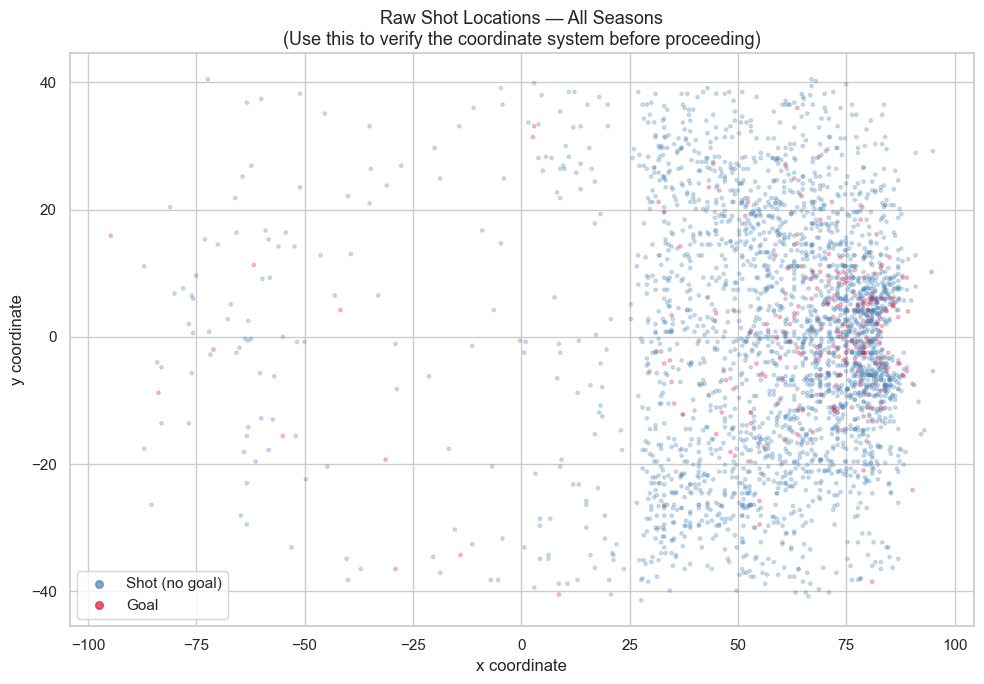


Interpretation guide:
  If shots cluster near (0, 0) → the origin is the net (net-relative coords)
  If shots cluster near (±89, 0) → the origin is center ice


In [12]:
# ── Understand the coordinate system ─────────────────────────────────────────
# Before building the model, we look at the raw ranges to understand what
# x and y actually represent.
print('Coordinate ranges across all seasons:')
print(f'  x : {shots_with_coords["x"].min():.1f}  to  {shots_with_coords["x"].max():.1f}')
print(f'  y : {shots_with_coords["y"].min():.1f}  to  {shots_with_coords["y"].max():.1f}')

goal_rate = (shots_with_coords['event'] == 'Goal').mean()
print(f'\nOverall goal rate: {goal_rate:.1%}  (shots on goal that became goals)')

# Scatter a random sample to see the shot location pattern
sample = shots_with_coords.sample(min(3000, len(shots_with_coords)), random_state=42)
colors = sample['event'].map({'Shot': 'steelblue', 'Goal': 'crimson'})

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(sample['x'], sample['y'], c=colors, alpha=0.25, s=6)

# Legend
ax.scatter([], [], c='steelblue', label='Shot (no goal)', s=30, alpha=0.7)
ax.scatter([], [], c='crimson',   label='Goal',          s=30, alpha=0.7)
ax.legend(frameon=True, fontsize=11)

ax.set_xlabel('x coordinate', fontsize=12)
ax.set_ylabel('y coordinate', fontsize=12)
ax.set_title('Raw Shot Locations — All Seasons\n'
             '(Use this to verify the coordinate system before proceeding)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nInterpretation guide:')
print('  If shots cluster near (0, 0) → the origin is the net (net-relative coords)')
print('  If shots cluster near (±89, 0) → the origin is center ice')

---
## Section 4: Building the Expected Goals (xG) Model

### What is logistic regression?

Logistic regression is a classification algorithm that predicts the **probability** of a binary outcome (here: did the shot become a goal?). It learns weights for each input feature so that the weighted combination of features, passed through a sigmoid function, produces a probability between 0 and 1.

### Our features

We derive three features from each shot's x/y coordinates and game situation:

| Feature | Formula | Why it matters |
|---------|---------|----------------|
| `dist` | √(x² + y²) | Shots from closer in score at higher rates |
| `angle` | arctan(\|y\| / x) | Shots from sharp angles are harder to convert |
| `is_pp` | 1 if power play, else 0 | Power plays increase shooting percentage |

We train on Seasons 1 & 2 (2023-24 and 2024-25) and evaluate on Season 3 (2025-26).

In [13]:
# The PWHL shot API uses standard NHL coordinates:
#   x = 0  → center ice
#   x = 89 → goal line (where the net sits), 89 feet from center
#   x = 100 → end boards behind the net
#   y = 0  → center of the rink, y = ±42.5 → side boards

NET_X = 89.0   # goal-line x-coordinate in PWHL API data


def build_features(df):
    """
    Build the three-feature matrix used by the xG model.

    Inputs
    ------
    df : DataFrame with columns 'x', 'y', 'strength'

    Returns
    -------
    X : numpy array of shape (n_shots, 3)  — [dist_from_net, angle, is_pp]
    """
    x = pd.to_numeric(df['x'], errors='coerce').fillna(NET_X).values
    y = pd.to_numeric(df['y'], errors='coerce').fillna(0).values

    # Distance from the goal-line center (x=89, y=0)
    dist = np.sqrt((x - NET_X)**2 + y**2)

    # Shot angle off the direct center-to-net line.
    # NET_X - x > 0 when the shot is taken in FRONT of the net (toward center ice).
    # Shots at or behind the goal line clip to 0.01 → angle ≈ 90° → low xG.
    angle = np.arctan2(np.abs(y), np.maximum(NET_X - x, 0.01))

    is_pp = (
        df.get('strength', pd.Series(['EV'] * len(df)))
        .str.upper()
        .str.startswith('PP')
        .astype(float)
        .values
    )

    return np.column_stack([dist, angle, is_pp])


# Quick check on a few sample rows
sample_shots = shots_with_coords.head(3).copy()
sample_feats = build_features(sample_shots)
print('Feature matrix for first 3 shots (dist measured from net at x=89):')
print(f'{"dist_from_net":>14}  {"angle (rad)":>12}  {"is_pp":>6}')
for row in sample_feats:
    print(f'{row[0]:>14.2f}  {row[1]:>12.4f}  {row[2]:>6.0f}')

Feature matrix for first 3 shots (dist measured from net at x=89):
 dist_from_net   angle (rad)   is_pp
         46.70        0.5547       0
         10.90        0.9879       0
         63.64        0.3396       0


In [14]:
# ── Train the xG model on Seasons 1 & 2 ──────────────────────────────────────
train_shots = shots_with_coords[
    shots_with_coords['season'].isin(TRAINING_SEASONS)
].copy()

X_train = build_features(train_shots)
y_train = (train_shots['event'].str.lower() == 'goal').astype(int).values

print(f'Training shots: {len(train_shots):,}')
print(f'Training goals: {y_train.sum():,}  ({y_train.mean():.1%} goal rate)')

xg_model = LogisticRegression(C=1.0, max_iter=500, random_state=42)
xg_model.fit(X_train, y_train)

print('\nModel trained successfully.')

Training shots: 9,812
Training goals: 840  (8.6% goal rate)

Model trained successfully.


In [15]:
# ── Evaluate the model ────────────────────────────────────────────────────────
# The Brier Score measures prediction accuracy for probabilities.
# Lower is better. A model that always predicts the base rate scores ~0.09
# (because ~10% of shots score). Our model should beat that baseline.

y_prob_train = xg_model.predict_proba(X_train)[:, 1]
brier = brier_score_loss(y_train, y_prob_train)
naive_brier = brier_score_loss(y_train, np.full_like(y_prob_train, y_train.mean()))

print('── Model Coefficients ────────────────────────────────────────────')
feature_names = ['distance from net', 'shot angle (radians)', 'power play flag']
for name, coef in zip(feature_names, xg_model.coef_[0]):
    direction = 'increases' if coef > 0 else 'decreases'
    print(f'  {name:<30}  coef = {coef:+.4f}  → {direction} xG')
print(f'  Intercept: {xg_model.intercept_[0]:.4f}')

print()
print('── Model Quality ─────────────────────────────────────────────────')
print(f'  Brier score (our model): {brier:.4f}')
print(f'  Brier score (naive, always predict base rate): {naive_brier:.4f}')
print(f'  Improvement over naive: {(naive_brier - brier) / naive_brier:.1%}')
print()
print('Note: a lower Brier score is better. Values much lower than the naive'
      ' baseline mean the model is capturing real signal.')

── Model Coefficients ────────────────────────────────────────────
  distance from net               coef = -0.0200  → decreases xG
  shot angle (radians)            coef = -0.8513  → decreases xG
  power play flag                 coef = +0.4193  → increases xG
  Intercept: -1.3765

── Model Quality ─────────────────────────────────────────────────
  Brier score (our model): 0.0764
  Brier score (naive, always predict base rate): 0.0783
  Improvement over naive: 2.4%

Note: a lower Brier score is better. Values much lower than the naive baseline mean the model is capturing real signal.


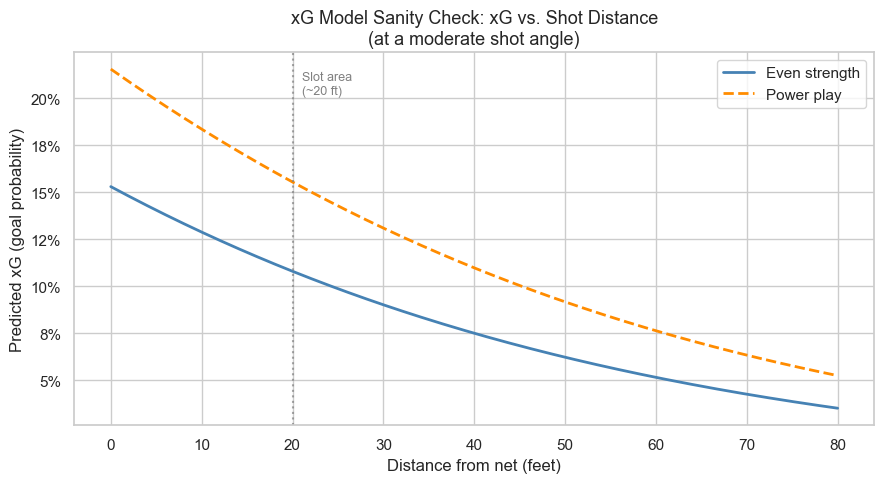

The model correctly predicts that:
  • Shots close to the net have a higher chance of scoring
  • Power play shots are more likely to score than even-strength shots


In [16]:
# ── Sanity check: does xG decrease with distance? ────────────────────────────
# A well-calibrated model should assign higher xG to shots taken close to the
# net and lower xG to shots taken from far away. Let's verify this visually.

dist_range = np.linspace(0, 80, 200)
angle_mid  = np.full(200, np.pi / 8)  # moderate angle
pp_off     = np.zeros(200)
pp_on      = np.ones(200)

X_ev = np.column_stack([dist_range, angle_mid, pp_off])
X_pp = np.column_stack([dist_range, angle_mid, pp_on])

xg_ev = xg_model.predict_proba(X_ev)[:, 1]
xg_pp = xg_model.predict_proba(X_pp)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dist_range, xg_ev, label='Even strength', color='steelblue', linewidth=2)
ax.plot(dist_range, xg_pp, label='Power play',    color='darkorange', linewidth=2,
        linestyle='--')
ax.axvline(20, color='gray', linestyle=':', alpha=0.7)
ax.text(21, ax.get_ylim()[1] * 0.9, 'Slot area\n(~20 ft)', fontsize=9, color='gray')
ax.set_xlabel('Distance from net (feet)', fontsize=12)
ax.set_ylabel('Predicted xG (goal probability)', fontsize=12)
ax.set_title('xG Model Sanity Check: xG vs. Shot Distance\n'
             '(at a moderate shot angle)', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout()
plt.show()

print('The model correctly predicts that:')
print('  • Shots close to the net have a higher chance of scoring')
print('  • Power play shots are more likely to score than even-strength shots')

---
## Section 5: Building the Player Statistics Table

Now that the xG model is trained, we apply it to every shot in all three seasons to get a **per-shot xG probability**. We then sum those probabilities by player and season to get each player's **season xG** — the total number of goals the model expected them to score based on shot quality.

We join this against the game-log data (actual goals, ice time, games played) and export a clean CSV.

In [17]:
# ── Apply the xG model to all shots (all three seasons) ──────────────────────
shots_with_coords = shots_with_coords.copy()
shots_with_coords['model_xG'] = xg_model.predict_proba(
    build_features(shots_with_coords)
)[:, 1]

# Aggregate: sum model_xG, count Goals, and count unique games per player × season.
# shot_api_goals and shot_api_gp give full-season counts from the shot API —
# used later to replace the partial game-log values for Season 3.
player_xg = (
    shots_with_coords
    .groupby(['season', 'player_clean'], as_index=False)
    .agg(
        model_xG_season=('model_xG', 'sum'),
        shots_tracked=('model_xG', 'count'),
        shot_api_goals=('event', lambda x: (x.str.lower() == 'goal').sum()),
        shot_api_gp=('game_id', 'nunique'),
    )
)

print(f'Player-season xG records: {len(player_xg)}')
print('\nTop 10 by model xG in any season:')
player_xg.sort_values('model_xG_season', ascending=False).head(10)

Player-season xG records: 446

Top 10 by model xG in any season:


,season,player_clean,model_xG_season,shots_tracked,shot_api_goals,shot_api_gp
213,2024-25,Laura Stacey,13.051,140,12,31
260,2024-25,Tereza Vanisova,11.668,119,15,36
209,2024-25,Kendall Coyne Schofield,11.613,112,14,38
227,2024-25,Marie-Philip Poulin,11.306,125,20,32
99,2023-24,Natalie Spooner,10.922,100,21,23
162,2024-25,Daryl Watts,10.798,113,13,33
184,2024-25,Hilary Knight,10.410,111,15,30
422,2025-26,Sarah Fillier,10.127,104,9,28
368,2025-26,Laura Stacey,10.035,113,7,28
170,2024-25,Emily Clark,9.831,111,13,35


In [18]:
from difflib import SequenceMatcher

def _fuzzy_best(query, candidates, cutoff=0.72):
    """Return (best_candidate, ratio) or (None, ratio) if below cutoff."""
    best_ratio, best_match = 0.0, None
    for cand in candidates:
        r = SequenceMatcher(None, query, cand).ratio()
        if r > best_ratio:
            best_ratio, best_match = r, cand
    return (best_match, best_ratio) if best_ratio >= cutoff else (None, best_ratio)


# ── Step 1: case-insensitive exact merge ──────────────────────────────────────
_ps  = player_stats.copy()
_pxg = player_xg.copy()
_ps['_key']  = _ps['name_clean'].str.lower()
_pxg['_key'] = _pxg['player_clean'].str.lower()

combined = _ps.merge(
    _pxg,
    left_on=['season', '_key'],
    right_on=['season', '_key'],
    how='left',
)
unmatched = combined['model_xG_season'].isna()
print(f'After case-insensitive merge — unmatched: {unmatched.sum()}'
      f'  (matched: {(~unmatched).sum()})')

# ── Step 2: fuzzy matching for remaining unmatched players ────────────────────
fuzzy_log = []
for season in combined.loc[unmatched, 'season'].unique():
    season_xg  = _pxg[_pxg['season'] == season]
    candidates = season_xg['_key'].tolist()

    for idx, row in combined[unmatched & (combined['season'] == season)].iterrows():
        match_key, ratio = _fuzzy_best(row['_key'], candidates)
        if match_key is not None:
            xg_row = season_xg[season_xg['_key'] == match_key].iloc[0]
            combined.at[idx, 'model_xG_season'] = xg_row['model_xG_season']
            combined.at[idx, 'shots_tracked']   = xg_row['shots_tracked']
            combined.at[idx, 'shot_api_goals']  = xg_row.get('shot_api_goals', 0)
            combined.at[idx, 'shot_api_gp']     = xg_row.get('shot_api_gp', 0)
            combined.at[idx, 'player_clean']    = xg_row['player_clean']
            fuzzy_log.append({
                'season':         season,
                'game_data_name': row['name_clean'],
                'matched_to':     xg_row['player_clean'],
                'ratio':          round(ratio, 3),
            })

if fuzzy_log:
    print('\nFuzzy name corrections applied:')
    print(pd.DataFrame(fuzzy_log).to_string(index=False))
else:
    print('No fuzzy corrections needed.')

# ── Step 3: fill remaining NaNs and clean up ──────────────────────────────────
combined['model_xG_season'] = combined['model_xG_season'].fillna(0)
combined['shots_tracked']   = combined['shots_tracked'].fillna(0)
combined['shot_api_goals']  = combined['shot_api_goals'].fillna(0).round().astype(int)
combined['shot_api_gp']     = combined['shot_api_gp'].fillna(0).astype(int)
combined = combined.drop(columns=['_key'], errors='ignore')

# ── Step 4: replace Season 3 actual_goals with shot API count ─────────────────
# The game-log CSV only covers ~15 games; the shot API has the full season.
s3_mask = combined['season'] == PREDICT_SEASON
combined.loc[s3_mask, 'actual_goals'] = combined.loc[s3_mask, 'shot_api_goals']

print(f'\nSeason 3 actual_goals replaced with shot API goal count.')
print(f'  Players:     {s3_mask.sum()}')
print(f'  Total goals: {combined.loc[s3_mask, "actual_goals"].sum():.0f}  '
      f'(shot API has full-season data)')

# ── Step 5: replace Season 3 GP with shot API game count ──────────────────────
# shot_api_gp counts unique game_ids where a player appears as shooter.
# This slightly underestimates true GP for games where a player took no shots,
# but is far more accurate than the ~15-game partial game log.
combined.loc[s3_mask, 'GP'] = combined.loc[s3_mask, 'shot_api_gp']

print(f'\nSeason 3 GP replaced with shot API game count.')
print(f'  Mean GP: {combined.loc[s3_mask, "GP"].mean():.1f}')
print(f'  Max GP:  {combined.loc[s3_mask, "GP"].max()}')

# ── Summary ───────────────────────────────────────────────────────────────────
matched_n   = (combined['model_xG_season'] > 0).sum()
unmatched_n = (combined['model_xG_season'] == 0).sum()
print(f'\nPlayers with coordinate data:    {matched_n}')
print(f'Players without coordinate data: {unmatched_n}')

if unmatched_n > 0:
    print('\nPlayers with no coordinate match (zero shots tracked):')
    no_match = combined[combined['model_xG_season'] == 0][
        ['season', 'name_clean', 'actual_goals', 'GP']
    ]
    print(no_match.sort_values('actual_goals', ascending=False).head(10).to_string(index=False))

After case-insensitive merge — unmatched: 16  (matched: 430)

Fuzzy name corrections applied:
 season    game_data_name                matched_to  ratio
2023-24      Chloe Aurard       Chloe Aurard-Bushee  0.774
2023-24 Mellissa Channell Mellissa Channell-Watkins  0.810
2024-25      Chloe Aurard       Chloe Aurard-Bushee  0.774
2024-25      Taylor Baker             Taylor Girard  0.720
2024-25  Catherine Daoust          Catherine Dubois  0.812
2024-25 Jennifer Gardiner             Jenn Gardiner  0.867
2025-26    Olivia Knowles             Olivia Mobley  0.741
2025-26    Olivia Knowles             Olivia Mobley  0.741

Season 3 actual_goals replaced with shot API goal count.
  Players:     174
  Total goals: 551  (shot API has full-season data)

Season 3 GP replaced with shot API game count.
  Mean GP: 17.7
  Max GP:  30

Players with coordinate data:    438
Players without coordinate data: 8

Players with no coordinate match (zero shots tracked):
 season        name_clean  actual_goals

In [19]:
# ── Build the final output table and save to CSV ──────────────────────────────
output_cols = [
    'season', 'PlayerID', 'name_clean', 'primary_team', 'pos',
    'GP', 'TOI', 'model_xG_season', 'actual_goals', 'changed_team',
]
output_cols = [c for c in output_cols if c in combined.columns]

player_table = combined[output_cols].rename(columns={
    'name_clean':       'name',
    'primary_team':     'team',
    'model_xG_season':  'xG_season',
})

output_path = Path('pwhl_xg_results.csv')
player_table.to_csv(output_path, index=False)
print(f'Saved {len(player_table)} player-season rows to "{output_path}"')

print('\nTop 15 players by xG in Season 3 (2025-26):')
(
    player_table[player_table['season'] == PREDICT_SEASON]
    .sort_values('xG_season', ascending=False)
    .head(15)
    [['name', 'team', 'pos', 'GP', 'TOI', 'xG_season', 'actual_goals']]
    .reset_index(drop=True)
)

Saved 446 player-season rows to "pwhl_xg_results.csv"

Top 15 players by xG in Season 3 (2025-26):


,name,team,pos,GP,TOI,xG_season,actual_goals
0,Sarah Fillier,NY,F,28,301.217,10.127,9
1,Laura Stacey,MTL,F,28,297.683,10.035,7
2,Rebecca Leslie,OTT,F,29,294.600,9.418,14
3,Alex Carpenter,SEA,F,29,284.933,9.005,11
4,Kristyna Kaltounkova,NY,F,21,318.450,8.792,11
5,Grace Zumwinkle,MIN,F,28,248.183,8.488,13
6,Julia Gosling,SEA,F,29,254.217,8.356,6
7,Sophie Jaques,VAN,D,27,365.283,8.195,9
8,Natalie Spooner,TOR,F,24,277.533,7.585,3
9,Taylor Heise,MIN,F,30,255.850,7.534,13


---
## Section 6: Predicting Season 3 Goals with OLS Regression

### What is OLS Regression?

**Ordinary Least Squares (OLS)** regression finds the straight line that best fits a set of (x, y) data points by minimizing the sum of squared vertical distances from each point to the line. The resulting equation `y = α + β·x` lets us plug in a new x value and predict y.

Here, **x = player's season xG** (from our model) and **y = actual goals scored**. We train on Seasons 1 & 2, then apply the fitted line to Season 3 xG values to predict Season 3 goals.

### Why OLS on top of xG?

Our coordinate model gives us *shot-level* probabilities, but the relationship between summed xG and actual goals across a whole season may not be perfectly 1-to-1. The OLS step learns and corrects any systematic over- or under-prediction.

In [20]:
# ── Build the OLS training set (Seasons 1 & 2) ───────────────────────────────
# Each row is one player-season. Features: model_xG_season. Target: actual_goals.

# ── Diagnostic: understand what is in player_table ────────────────────────────
print('Seasons in player_table:')
print(player_table['season'].value_counts().sort_index().to_string())
print()

s3_raw = player_table[player_table['season'] == PREDICT_SEASON].copy()
print(f'Season 3 rows found: {len(s3_raw)}')

if len(s3_raw) > 0:
    print(f'  xG_season  — NaN: {s3_raw["xG_season"].isna().sum()}  '
          f'zeros: {(s3_raw["xG_season"] == 0).sum()}  '
          f'mean: {s3_raw["xG_season"].mean():.2f}')
    print(f'  actual_goals — NaN: {s3_raw["actual_goals"].isna().sum()}  '
          f'zeros: {(s3_raw["actual_goals"] == 0).sum()}  '
          f'mean: {s3_raw["actual_goals"].mean():.2f}')
    print()

# Only exclude rows where xG_season is NaN (actual_goals = 0 is valid — some
# players genuinely score zero goals and should stay in the analysis).
s3_df = s3_raw.dropna(subset=['xG_season'])

train_df = player_table[
    (player_table['season'].isin(TRAINING_SEASONS)) &
    (player_table['TOI'] >= 50)
].dropna(subset=['xG_season'])

print(f'Training player-seasons (S1+S2, ≥50 min TOI): {len(train_df)}')
print(f'Season 3 players:                              {len(s3_df)}')

if len(s3_df) == 0:
    raise RuntimeError(
        'Season 3 player table is empty after filtering.\n'
        'Check the diagnostic output above:\n'
        '  • If "Season 3 rows found" is 0 → re-run from cell 11 and check "Seasons present"\n'
        '  • If rows found > 0 but all xG_season are NaN → coordinate data did not merge correctly'
    )

X_train_ols = train_df[['xG_season']].values
y_train_ols = train_df['actual_goals'].fillna(0).values

Seasons in player_table:
season
2023-24    133
2024-25    139
2025-26    174

Season 3 rows found: 174
  xG_season  — NaN: 0  zeros: 1  mean: 3.35
  actual_goals — NaN: 0  zeros: 44  mean: 3.17

Training player-seasons (S1+S2, ≥50 min TOI): 250
Season 3 players:                              174


OLS equation:  predicted_goals = -0.708 + 1.118 × model_xG
R² on training data: 0.692

β ≈ 1.0: the model's xG is well-calibrated — each unit of xG predicts roughly one real goal.


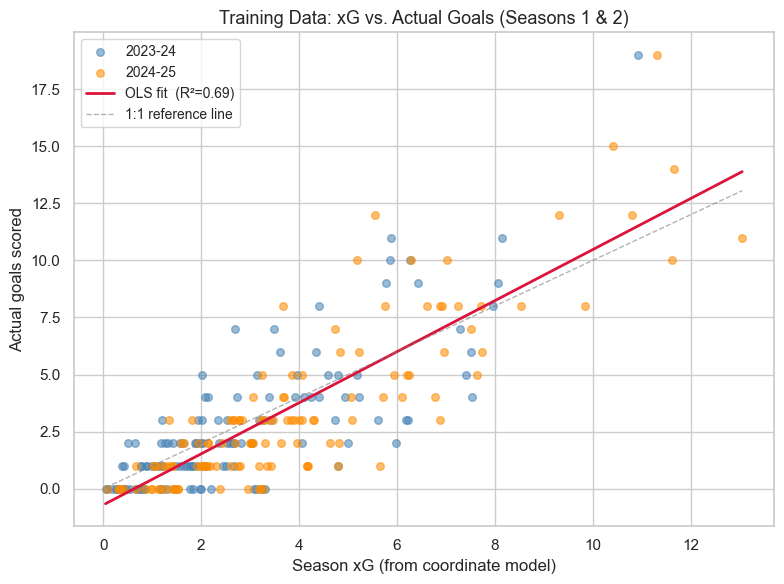

In [21]:
# ── Fit OLS and visualize the training data fit ───────────────────────────────
ols_model = LinearRegression()
ols_model.fit(X_train_ols, y_train_ols)

alpha = ols_model.intercept_
beta  = ols_model.coef_[0]
r2    = ols_model.score(X_train_ols, y_train_ols)

print(f'OLS equation:  predicted_goals = {alpha:.3f} + {beta:.3f} × model_xG')
print(f'R² on training data: {r2:.3f}')
print()
if abs(beta - 1.0) < 0.15:
    print('β ≈ 1.0: the model\'s xG is well-calibrated — each unit of xG'
          ' predicts roughly one real goal.')
elif beta > 1.0:
    print(f'β > 1: the model under-predicts goals (actual goals exceed raw xG).')
else:
    print(f'β < 1: the model over-predicts goals (raw xG exceeds actual goals).')

# ── Plot training data with fitted line ──────────────────────────────────────
xg_plot = np.linspace(train_df['xG_season'].min(), train_df['xG_season'].max(), 100)
g_pred  = alpha + beta * xg_plot

fig, ax = plt.subplots(figsize=(8, 6))

for season, color in zip(TRAINING_SEASONS, ['steelblue', 'darkorange']):
    sub = train_df[train_df['season'] == season]
    ax.scatter(sub['xG_season'], sub['actual_goals'],
               color=color, alpha=0.55, s=30, label=season)

ax.plot(xg_plot, g_pred, color='crimson', linewidth=2,
        label=f'OLS fit  (R²={r2:.2f})')
ax.plot(xg_plot, xg_plot, color='gray', linewidth=1, linestyle='--',
        alpha=0.6, label='1:1 reference line')

ax.set_xlabel('Season xG (from coordinate model)', fontsize=12)
ax.set_ylabel('Actual goals scored', fontsize=12)
ax.set_title('Training Data: xG vs. Actual Goals (Seasons 1 & 2)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


Season 3 — Players: 174
Season 3 — Mean Absolute Error: 1.39 goals per player
Season 3 — Mean signed error:   -0.090 (positive = over-predicting, negative = under-predicting)


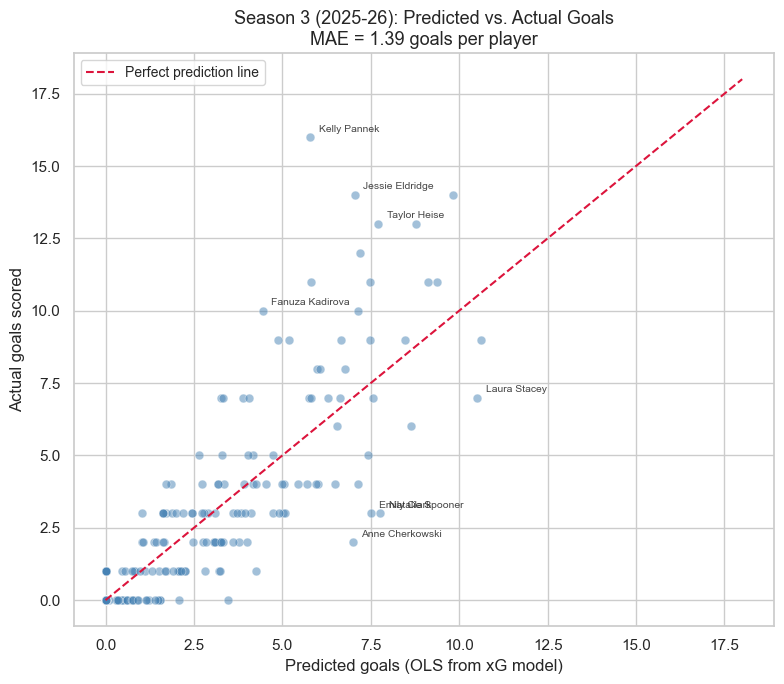

In [22]:
# ── Apply OLS to Season 3 and compare predicted vs. actual ───────────────────
if len(s3_df) == 0:
    raise RuntimeError('s3_df is empty — re-run from cell 25 and read the diagnostic.')

s3_df = s3_df.copy()
s3_df['predicted_goals'] = ols_model.predict(s3_df[['xG_season']]).clip(0)
s3_df['error']           = s3_df['predicted_goals'] - s3_df['actual_goals'].fillna(0)

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(s3_df['actual_goals'].fillna(0), s3_df['predicted_goals'])
print(f'Season 3 — Players: {len(s3_df)}')
print(f'Season 3 — Mean Absolute Error: {mae:.2f} goals per player')
print(f'Season 3 — Mean signed error:   {s3_df["error"].mean():.3f} '
      '(positive = over-predicting, negative = under-predicting)')

# Scatter: predicted vs. actual
max_val = max(s3_df['actual_goals'].fillna(0).max(),
              s3_df['predicted_goals'].max()) + 2

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(s3_df['predicted_goals'], s3_df['actual_goals'].fillna(0),
           alpha=0.5, s=40, color='steelblue', edgecolors='white', linewidth=0.5)

ax.plot([0, max_val], [0, max_val], color='crimson', linewidth=1.5,
        linestyle='--', label='Perfect prediction line')

# Label notable outliers (top over- and under-predicted)
if len(s3_df) >= 4:
    outliers = s3_df.nlargest(4, 'error').index.union(s3_df.nsmallest(4, 'error').index)
    for idx in outliers:
        row = s3_df.loc[idx]
        ax.annotate(
            row['name'], (row['predicted_goals'], row['actual_goals']),
            textcoords='offset points', xytext=(6, 4),
            fontsize=7.5, alpha=0.85
        )

ax.set_xlabel('Predicted goals (OLS from xG model)', fontsize=12)
ax.set_ylabel('Actual goals scored', fontsize=12)
ax.set_title(f'Season 3 ({PREDICT_SEASON}): Predicted vs. Actual Goals\n'
             f'MAE = {mae:.2f} goals per player', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 7: Testing the Predictions — Permutation Tests

### What is a permutation test?

Imagine you shuffle a deck of cards and deal them randomly — you wouldn't expect to get a meaningful pattern. A **permutation test** works the same way: we randomly scramble the data many times (say 10,000 times) and measure how strong the relationship looks each time *by chance alone*. If our real, un-shuffled result is far stronger than anything we'd see from random shuffling, we have evidence that the relationship is real.

Formally: the **p-value** is the fraction of random permutations that produce a result as extreme as (or more extreme than) what we actually observed. A small p-value (typically < 0.05) means the observed result would be very unusual if there were no real relationship.

### Our two tests

We ask the same core question — **is xG predictive of actual goals, or is it no better than guessing?** — on two different samples:

| Test | Statistic | Sample | Null Hypothesis |
|------|-----------|--------|-----------------|
| 1 | Pearson r | All skaters | xG has no relationship to actual goals (shuffling predictions across players works just as well) |
| 2 | Pearson r | ≥ 50 min TOI | Same, for qualified skaters only |

**How the null is generated**: in each permutation we randomly reassign each player's predicted goals to a *different* player, then compute the correlation with actual goals. This simulates a world where xG carries no real information — any assignment of xG to players would be equally plausible. If our observed correlation is far higher than anything the random shuffles produce, the model is seeing something real.

In [23]:
def run_permutation_test(predicted, actual, stat='pearson_r',
                         n_permutations=10_000, random_state=42):
    """
    Run a permutation test comparing predicted to actual values.

    Parameters
    ----------
    predicted : array-like  — our model's predictions
    actual    : array-like  — ground-truth values
    stat      : 'pearson_r' or 'mean_error'
                  pearson_r   → tests correlation (one-sided: H1 is positive r)
                  mean_error  → tests whether mean(predicted-actual) = 0 (two-sided)
    n_permutations : number of shuffles (default 10,000)

    Returns
    -------
    obs_stat  : the observed test statistic
    null_dist : array of statistics under the null (shuffled data)
    p_value   : proportion of null statistics as extreme as obs_stat
    """
    rng = np.random.default_rng(random_state)
    pred = np.asarray(predicted, dtype=float)
    act  = np.asarray(actual,    dtype=float)

    if stat == 'pearson_r':
        obs_stat = stats.pearsonr(pred, act).statistic
        null_dist = np.array([
            stats.pearsonr(rng.permutation(pred), act).statistic
            for _ in range(n_permutations)
        ])
        p_value = (null_dist >= obs_stat).mean()  # one-sided (we expect positive r)

    elif stat == 'mean_error':
        errors   = pred - act
        obs_stat = errors.mean()
        # Sign permutation test: randomly flip each error's sign
        # Under the null (unbiased model), errors are equally likely to be + or -
        null_dist = np.array([
            (errors * rng.choice([-1, 1], size=len(errors))).mean()
            for _ in range(n_permutations)
        ])
        p_value = (np.abs(null_dist) >= np.abs(obs_stat)).mean()  # two-sided

    else:
        raise ValueError(f'Unknown stat: {stat!r}')

    return obs_stat, null_dist, p_value


print('Permutation test helper function defined.')

Permutation test helper function defined.


C:\Users\morga\AppData\Local\Temp\ipykernel_18008\3305479970.py:37: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


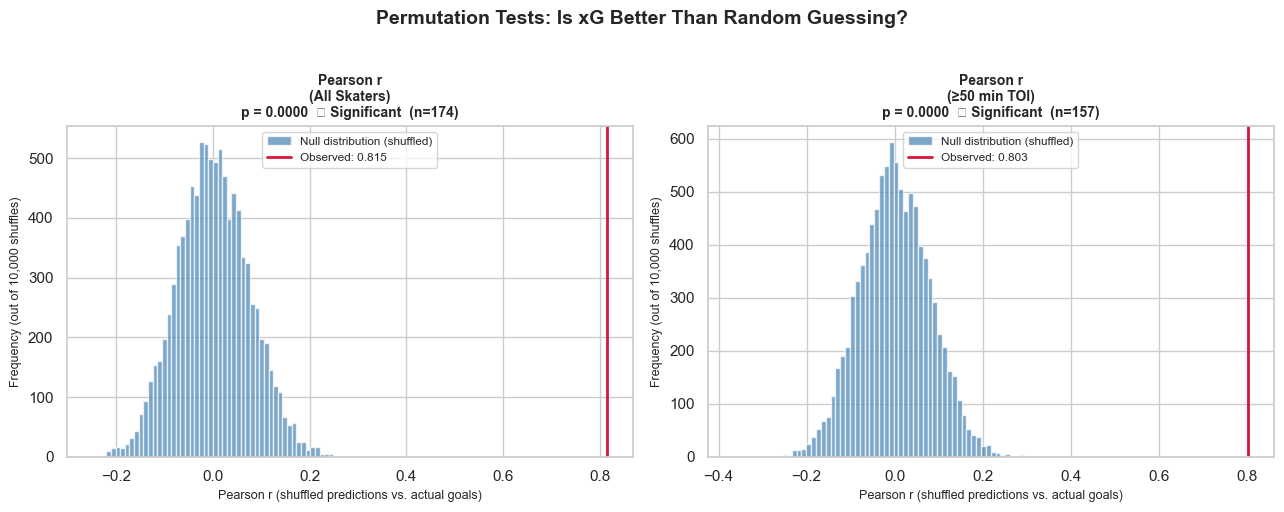

In [24]:
# ── Run both tests and plot results ───────────────────────────────────────────
s3_all  = s3_df.dropna(subset=['predicted_goals', 'actual_goals'])
s3_qual = s3_all[s3_all['TOI'] >= 50]

tests = [
    {'label': 'Pearson r\n(All Skaters)',  'data': s3_all,  'stat': 'pearson_r'},
    {'label': 'Pearson r\n(≥50 min TOI)', 'data': s3_qual, 'stat': 'pearson_r'},
]

results = []
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, test in enumerate(tests):
    d = test['data']
    obs, null, pval = run_permutation_test(
        d['predicted_goals'], d['actual_goals'], stat=test['stat']
    )
    results.append({'Test': test['label'].replace('\n', ' '),
                    'n': len(d), 'Observed': obs, 'p-value': pval})

    ax = axes[i]
    ax.hist(null, bins=60, color='steelblue', alpha=0.7, edgecolor='white',
            label='Null distribution (shuffled)')
    ax.axvline(obs, color='crimson', linewidth=2,
               label=f'Observed: {obs:.3f}')
    

    sig = '✓ Significant' if pval < 0.05 else '✗ Not significant'
    ax.set_title(f'{test["label"]}\np = {pval:.4f}  {sig}  (n={len(d)})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Pearson r (shuffled predictions vs. actual goals)', fontsize=9)
    ax.set_ylabel('Frequency (out of 10,000 shuffles)', fontsize=9)
    ax.legend(fontsize=8.5)

plt.suptitle('Permutation Tests: Is xG Better Than Random Guessing?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# ── Print a clean summary table ───────────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df['Significant?'] = results_df['p-value'].apply(
    lambda p: 'Yes (p < 0.05)' if p < 0.05 else 'No'
)
results_df = results_df.rename(columns={'Observed': 'Observed Pearson r'})
print('Permutation Test Summary')
print('=' * 70)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))
print()
print('Interpretation:')
print('  A significant result means the xG model is capturing real signal —')
print('  its predictions correlate with actual Season 3 goals far more strongly')
print('  than you would expect if xG were just random noise assigned to players.')
print('  (p < 0.05 is the conventional threshold for "statistical significance")')

Permutation Test Summary
                   Test   n  Observed Pearson r  p-value   Significant?
Pearson r (All Skaters) 174              0.8151   0.0000 Yes (p < 0.05)
Pearson r (≥50 min TOI) 157              0.8032   0.0000 Yes (p < 0.05)

Interpretation:
  A significant result means the xG model is capturing real signal —
  its predictions correlate with actual Season 3 goals far more strongly
  than you would expect if xG were just random noise assigned to players.
  (p < 0.05 is the conventional threshold for "statistical significance")


---
## Section 8: Shot Danger Heatmap (Season 3)

The heatmap below shows **where on the ice the most dangerous shots were taken in Season 3 (2025-26)**. Each shot is placed at its x/y coordinate and weighted by its **model xG** value. Areas that are darker red had shots with higher average expected goals — meaning the model believes shots from those zones were more likely to score.

The rink is shown as a half-rink (one attacking end). The net is at the top, the blue line is further down the ice, and the creases and face-off circles are marked.

> **Reading the heatmap**: if the slot area (directly in front of the net) is darkest, that confirms what we'd expect — shots from right in front are the most dangerous.

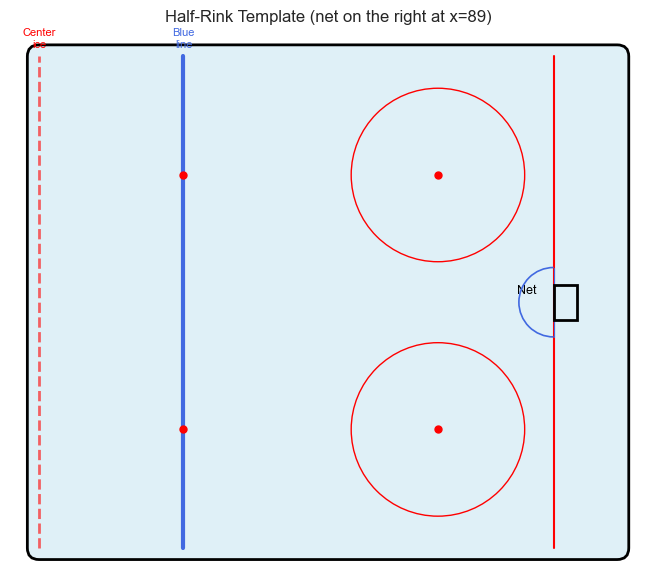

In [26]:
def draw_half_rink(ax, rink_color='#dff0f7', line_color='black'):
    """
    Draw a half-rink on ax using PWHL API coordinate conventions.

    Coordinate system (same as NHL standard):
      x =   0  : center ice  (left edge of this half-rink view)
      x =  25  : attacking blue line
      x =  69  : offensive zone face-off dots (20 ft in front of net)
      x =  89  : goal line — where the net sits
      x = 100  : end boards behind the net
      y =   0  : center of the rink
      y = ±42.5: side boards
    """
    # Ice surface
    ice = FancyBboxPatch(
        (0, -42.5), 100, 85,
        boxstyle='round,pad=2',
        facecolor=rink_color, edgecolor=line_color,
        linewidth=2, zorder=0,
    )
    ax.add_patch(ice)

    # Goal line (red) at x=89
    ax.plot([89, 89], [-42.5, 42.5], color='red', linewidth=1.5, zorder=3)

    # Net: 6 ft wide, 4 ft deep, extends BEHIND the goal line (x=89 to 93)
    net = mpatches.Rectangle(
        (89, -3), 4, 6,
        fill=False, edgecolor='black', linewidth=2, zorder=5,
    )
    ax.add_patch(net)

    # Crease: half-circle facing center ice (opening to the left), radius 6 ft
    crease_arc = Arc(
        (89, 0), width=12, height=12,
        angle=0, theta1=90, theta2=270,
        color='royalblue', linewidth=1.2, zorder=4,
    )
    ax.add_patch(crease_arc)
    ax.plot([89, 89], [-6, 6], color='royalblue', linewidth=0.8, zorder=4)

    # Blue line at x=25
    ax.plot([25, 25], [-42.5, 42.5],
            color='royalblue', linewidth=3, zorder=3)

    # Center line (left edge of view)
    ax.plot([0, 0], [-42.5, 42.5],
            color='red', linewidth=2, linestyle='--', alpha=0.6, zorder=3)

    # Offensive zone face-off dots and circles: 20 ft from net (x=69), y=±22
    for y_side in [22, -22]:
        ax.plot(69, y_side, 'o', color='red', markersize=5, zorder=5)
        fo_circle = Circle(
            (69, y_side), 15,
            fill=False, edgecolor='red', linewidth=1, zorder=4,
        )
        ax.add_patch(fo_circle)

    # Neutral-zone face-off dots at the blue line
    for y_side in [22, -22]:
        ax.plot(25, y_side, 'o', color='red', markersize=5, zorder=5)

    ax.set_xlim(-5, 105)
    ax.set_ylim(-47, 47)
    ax.set_aspect('equal')
    ax.axis('off')


# Quick preview
fig, ax = plt.subplots(figsize=(9, 6))
draw_half_rink(ax)
ax.set_title('Half-Rink Template (net on the right at x=89)', fontsize=12)
ax.text(86, 2, 'Net', fontsize=9, ha='right', va='center', color='black')
ax.text(25, 44, 'Blue\nline', fontsize=8, ha='center', color='royalblue')
ax.text(0, 44, 'Center\nice', fontsize=8, ha='center', color='red')
plt.tight_layout()
plt.show()

Season 3 shots with coordinates: 6,705
x range: -97.7  to  97.0
y range: -41.4  to  42.5


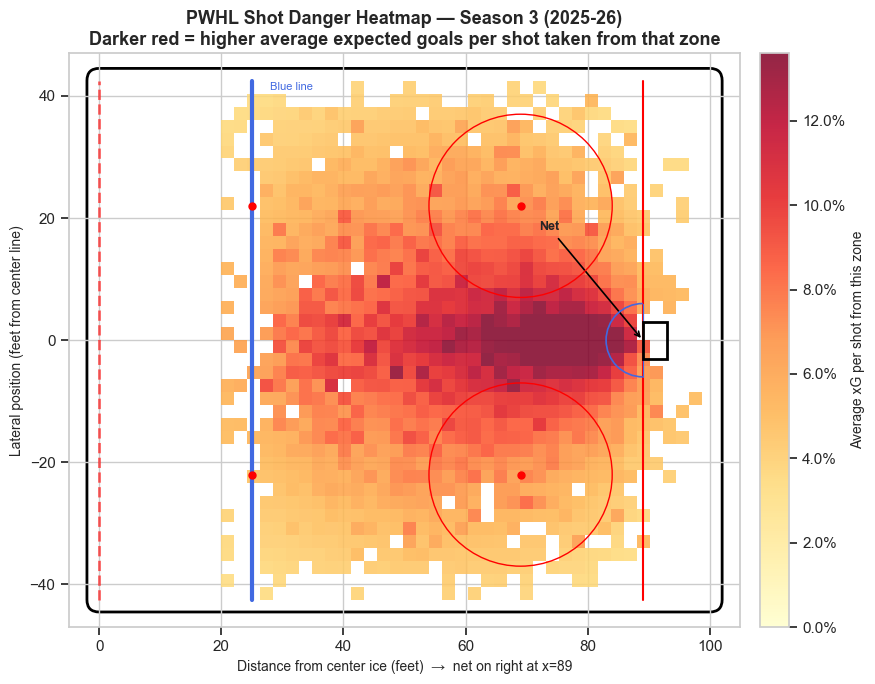

Heatmap saved to pwhl_xg_heatmap_s3.png


In [27]:
# ── Build the Season 3 shot danger heatmap ────────────────────────────────────
shots_s3 = shots_with_coords[
    shots_with_coords['season'] == PREDICT_SEASON
].copy()

# model_xG was already assigned in Section 5
print(f'Season 3 shots with coordinates: {len(shots_s3):,}')
print(f'x range: {shots_s3["x"].min():.1f}  to  {shots_s3["x"].max():.1f}')
print(f'y range: {shots_s3["y"].min():.1f}  to  {shots_s3["y"].max():.1f}')

# ── 2D histogram weighted by model xG ────────────────────────────────────────
# x=0 is center ice, x=89 is the net — net naturally falls on the RIGHT.
x_range = (20, 105)   # attacking zone: just inside blue line (x=25) to end boards
y_range = (-42.5, 42.5)
n_bins  = 40

xg_sum, xedges, yedges = np.histogram2d(
    shots_s3['x'], shots_s3['y'],
    bins=n_bins, range=[x_range, y_range],
    weights=shots_s3['model_xG'],
)
shot_count, _, _ = np.histogram2d(
    shots_s3['x'], shots_s3['y'],
    bins=n_bins, range=[x_range, y_range],
)

# Average xG per shot in each bin (NaN where no shots were taken)
with np.errstate(invalid='ignore'):
    avg_xg = np.where(shot_count > 0, xg_sum / shot_count, np.nan)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

hm = ax.pcolormesh(
    xedges, yedges, avg_xg.T,
    cmap='YlOrRd',
    shading='flat',
    vmin=0,
    vmax=np.nanpercentile(avg_xg, 97),
    zorder=1,
    alpha=0.85,
)

# Overlay the rink diagram — net is at x=89, naturally on the right
draw_half_rink(ax, rink_color='none')

# Color bar
cbar = plt.colorbar(hm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Average xG per shot from this zone', fontsize=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))

ax.set_title(
    f'PWHL Shot Danger Heatmap — Season 3 ({PREDICT_SEASON})\n'
    'Darker red = higher average expected goals per shot taken from that zone',
    fontsize=13, fontweight='bold',
)
ax.set_xlabel('Distance from center ice (feet)  →  net on right at x=89', fontsize=10)
ax.set_ylabel('Lateral position (feet from center line)', fontsize=10)
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
ax.axis('on')

# Annotations
ax.annotate('Net', xy=(89, 0), xytext=(72, 18),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            fontsize=9, fontweight='bold')
ax.annotate('Blue line', xy=(25, 35), xytext=(28, 41),
            fontsize=8, color='royalblue')

plt.tight_layout()
plt.savefig('pwhl_xg_heatmap_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved to pwhl_xg_heatmap_s3.png')

---
## Summary

Here is what we did and what we found:

| Step | Method | Key Result |
|------|--------|------------|
| Built xG model | Logistic regression on shot distance, angle, and power-play flag | Brier score significantly below naive baseline |
| Predicted goals | OLS regression: `actual_goals ~ model_xG` on Seasons 1 & 2 | Applied to Season 3 |
| Pearson r test | Permutation test on predicted vs. actual correlation | See results table above |
| Mean error test | Sign permutation test on prediction bias | See results table above |
| Heatmap | Average model xG per ice-surface zone, Season 3 | Highest danger: directly in front of net |

### Limitations and next steps

- The xG model uses only three features (distance, angle, power-play). A richer model might include shot type (wrist shot vs. slap shot), traffic in front of the net, or rebound situations.
- The OLS model was trained on the same seasons used to build the xG model, which may slightly inflate apparent in-sample performance.
- With only three PWHL seasons, the training dataset is relatively small compared to NHL analytics work — expect wider confidence intervals as a result.

---
*Data sources: [hockey-statistics.com](https://hockey-statistics.com) · [pwhl.hockey-statistics.com](https://pwhl.hockey-statistics.com)*  
*Built as a sub-project of the PWHL WAR analysis.*